In [27]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))

from src.config import project_io, secrets
from src.spotify_handler import SpotifyHandler
from src.database import SpotifyDB

In [28]:
db = SpotifyDB(db_path=secrets.database_url)

In [29]:
enriched_streams = db.query("SELECT * FROM enriched_streams ORDER BY [timestamp]").df()
original_shape = enriched_streams.shape
# For how long did I listen to each media?
enriched_streams = enriched_streams.assign(
    time_played=enriched_streams["timestamp"].diff().shift(-1)
)
# COnvert time_played to seconds
enriched_streams["time_played"] = enriched_streams["time_played"].dt.total_seconds()
# Let's drop columns related to audiobooks and podcasts
podcast_audiobook_columns = [
    col for col in enriched_streams.columns if "episode" in col or "audiobook" in col
]
enriched_streams = enriched_streams.drop(columns=podcast_audiobook_columns)

# Let's look at only songs with audio features
# To keep it simple, we can use `dancability` as a proxy for songs with audio features
enriched_streams = enriched_streams.loc[enriched_streams["danceability"].notna()]

In [30]:
# How many records we have left and what percent of the original data is that?
final_shape = enriched_streams.shape
print(f"Original shape: {original_shape}")
print(f"Final shape: {final_shape:}")
print(f"Percent of original data: {final_shape[0] / original_shape[0] * 100:.2f}%")

Original shape: (213890, 59)
Final shape: (37002, 53)
Percent of original data: 17.30%


While we only retained 17% of our original dataset, it should still be plenty for analysis at a size of 37k records.

## EDA

In [67]:
import pandas as pd
from plotnine import (
    ggplot,
    aes,
    geom_line,
    geom_point,
    geom_bar,
    geom_histogram,
    facet_wrap,
    scale_x_continuous,
    scale_fill_brewer,
    labs,
    theme_minimal,
    theme,
    element_text,
    geom_density,
)

# --- 1. Songs listened to per year ---
songs_per_year = (
    enriched_streams.groupby("year_stream", as_index=False).size().rename(columns={"size": "count"})
)

p1 = (
    ggplot(songs_per_year, aes(x="year_stream", y="count"))
    + geom_line(color="#1DB954", size=1)
    + geom_point(color="#1DB954", size=3)
    + scale_x_continuous(breaks=songs_per_year["year_stream"].tolist())
    + labs(title="Songs Listened to Per Year", x="Year", y="Stream Count")
    + theme_minimal()
    + theme(axis_text_x=element_text(rotation=45))
)

# --- 2. Stream count per season, split by time of day ---
season_order = ["Winter", "Spring", "Summer", "Autumn"]
tod_order = ["Morning", "Afternoon", "Evening", "Night"]

streams_by_season_tod = enriched_streams.copy()
streams_by_season_tod["season"] = pd.Categorical(
    streams_by_season_tod["season"], categories=season_order, ordered=True
)
streams_by_season_tod["time_of_day"] = pd.Categorical(
    streams_by_season_tod["time_of_day"], categories=tod_order, ordered=True
)

p2 = (
    ggplot(streams_by_season_tod, aes(x="season", fill="time_of_day"))
    + geom_bar()
    + scale_fill_brewer(type="qual", palette="Set2")
    + labs(title="Streams per Season by Time of Day", x="Season", y="Count", fill="Time of Day")
    + theme_minimal()
)
# --- 3. Stream proportion per season, split by time of day ---
p3 = (
    ggplot(streams_by_season_tod, aes(x="season", fill="time_of_day"))
    + geom_bar(position="fill")
    + scale_fill_brewer(type="qual", palette="Set2")
    + labs(title="Streams per Season by Time of Day", x="Season", y="Count", fill="Time of Day")
    + theme_minimal()
)

# --- 4. Side-by-side histograms: ms_played vs time_played (both in seconds) ---
# Note: This graph is to check how well `ms_played` (converted to seconds) aligns with `time_played` (in seconds)
#  and to see if there are any discrepancies in their distributions.
play_dist = enriched_streams[["ms_played", "time_played"]].copy()
play_dist["ms_played_s"] = play_dist["ms_played"] / 1000

long_dist = (
    pd.melt(play_dist[["ms_played_s", "time_played"]], var_name="metric", value_name="seconds")
    .assign(
        metric=lambda df: df["metric"].map(
            {"ms_played_s": "ms_played (converted to s)", "time_played": "time_played (s)"}
        )
    )
    .query("seconds <= 600")
)  # cap at 10 min to focus on main distribution

p4 = (
    ggplot(long_dist, aes(x="seconds", fill="metric"))
    + geom_histogram(bins=60, alpha=0.8, color="white")
    + facet_wrap("metric", ncol=2)
    + scale_fill_brewer(type="qual", palette="Set1")
    + labs(title="Distribution: ms_played vs time_played", x="Seconds", y="Count", fill="Metric")
    + theme_minimal()
    + theme(legend_position="none")
)

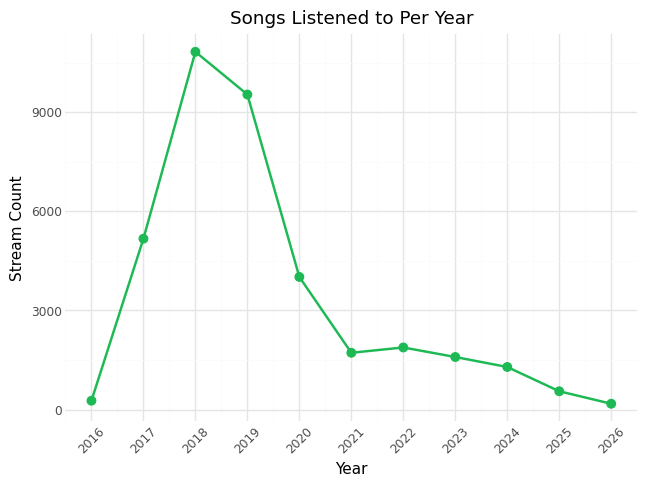

In [68]:
p1.draw()

It does not surprise me that I listen to the most music in the winter and spring since these are the months I tend to stay the most indoors. I listen to music in the background or I discover new albums

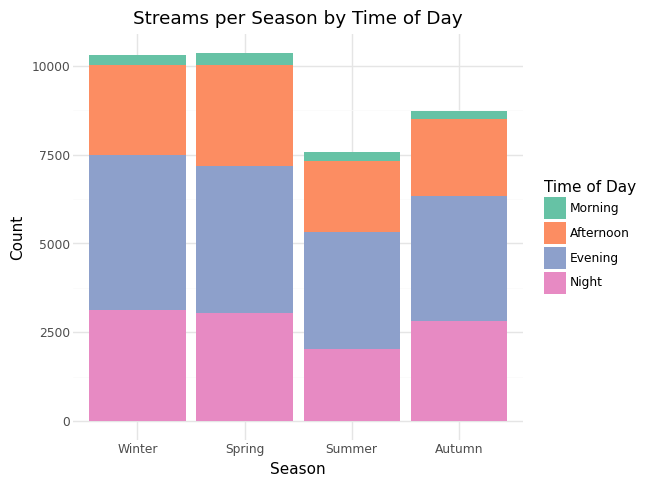

In [69]:
p2.draw()

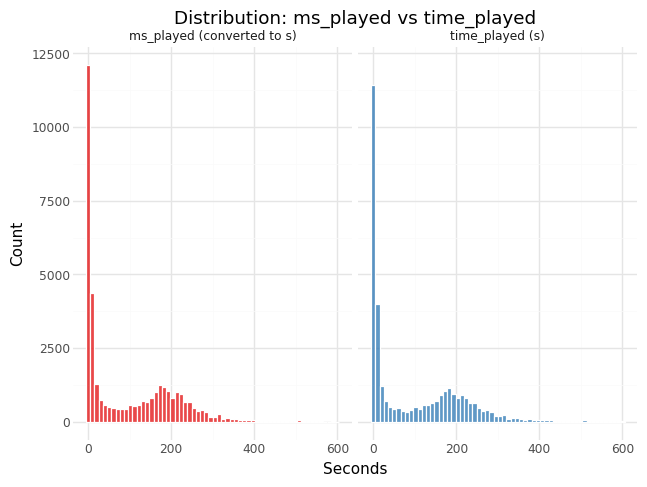

In [70]:
p4.draw()

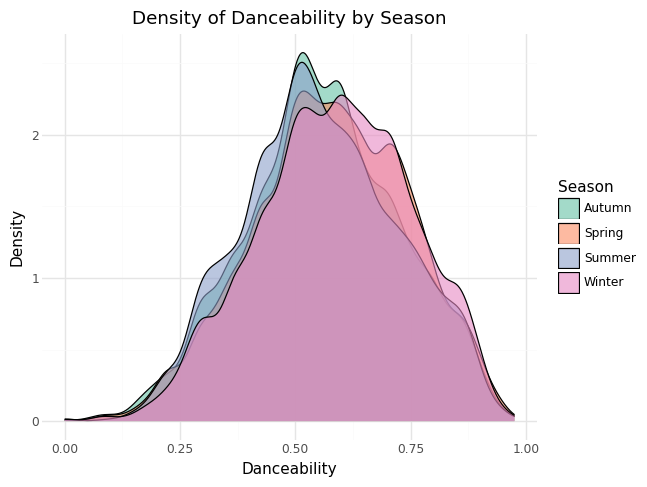

In [ ]:
## Let's also visualize two audio features: `danceability` and `energy` across seasons.


# Distriubtion of dancability across seasons
p5 = (
    ggplot(enriched_streams, aes(x="danceability", fill="season"))
    + geom_density(alpha=0.6)
    + scale_fill_brewer(type="qual", palette="Set2")
    + labs(title="Density of Danceability by Season", x="Danceability", y="Density", fill="Season")
    + theme_minimal()
)
p5.draw()

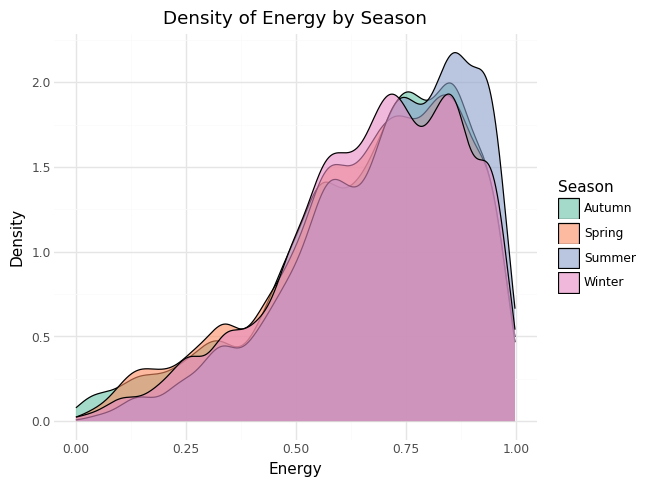

In [84]:
# Distrubution of energy across seasons
p6 = (
    ggplot(enriched_streams, aes(x="energy", fill="season"))
    + geom_density(alpha=0.6)
    + scale_fill_brewer(type="qual", palette="Set2")
    + labs(title="Density of Energy by Season", x="Energy", y="Density", fill="Season")
    + theme_minimal()
)
p6.draw()

## Hypothesis testing

### Is the mean number of daily streams significantly different across seasons?
$H_{0}$: There is no differnece among the count of streams per season.
$H_{A}$: There is a differencea among the count of streams per season.


/Users/abrahambriones/Projects/Spotify_ML_Demo/.venv/lib/python3.13/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_bin : Removed 14 rows containing non-finite values.
/Users/abrahambriones/Projects/Spotify_ML_Demo/.venv/lib/python3.13/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_histogram : Removed 8 rows containing missing values.


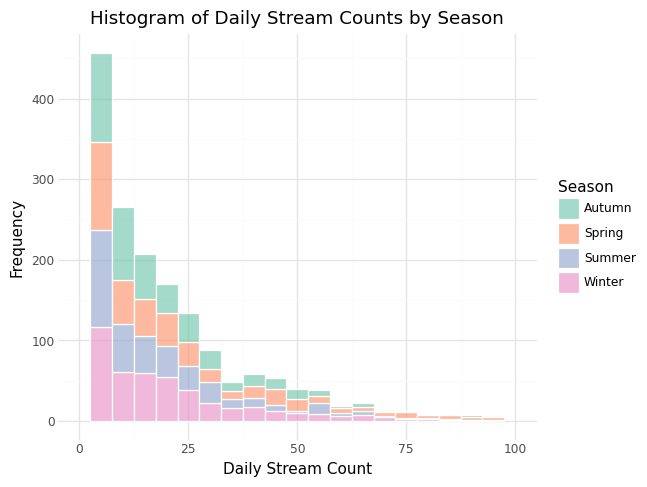

In [81]:
# Let's see the histogram of daily stream counts by season to get a visual sense of the differences
# and limit the x-axis from 0 to 100 to focus on the main distribution
p5 = (
    ggplot(daily_streams, aes(x="daily_count", fill="season"))
    + geom_histogram(alpha=0.6, binwidth=5, color="white")
    + scale_fill_brewer(type="qual", palette="Set2")
    + scale_x_continuous(limits=(0, 100))
    + labs(
        title="Histogram of Daily Stream Counts by Season",
        x="Daily Stream Count",
        y="Frequency",
        fill="Season",
    )
    + theme_minimal()
)
p5.draw()

In [82]:
from scipy import stats
import scikit_posthocs as sp

# Aggregate to daily stream counts with season label
daily_streams = (
    enriched_streams.assign(date=enriched_streams["timestamp"].dt.date)
    .groupby(["date", "season"], as_index=False)
    .size()
    .rename(columns={"size": "daily_count"})
)

# Split into groups by season
groups = {
    season: daily_streams.loc[daily_streams["season"] == season, "daily_count"].values
    for season in season_order
}

# Kruskal-Wallis test
stat, p_value = stats.kruskal(*groups.values())
kruskal_result = {"H-statistic": round(stat, 4), "p-value": round(p_value, 6)}

# Dunn's post-hoc (Bonferroni correction) if significant
dunn_result = sp.posthoc_dunn(
    daily_streams, val_col="daily_count", group_col="season", p_adjust="bonferroni"
)

if kruskal_result.get("p-value") < 0.05:
    print("Kruskal-Wallis test is significant. Performing Dunn's post-hoc test:")
    print(dunn_result)
else:
    print("Kruskal-Wallis test is not significant. No need for post-hoc tests.")

Kruskal-Wallis test is significant. Performing Dunn's post-hoc test:
          Autumn    Spring    Summer    Winter
Autumn  1.000000  1.000000  0.760609  0.090165
Spring  1.000000  1.000000  0.052032  1.000000
Summer  0.760609  0.052032  1.000000  0.000551
Winter  0.090165  1.000000  0.000551  1.000000


The post-hoc test reveals the following differences (adjusted $p < 0.05$ ):
- Summer vs Autumn and Spring
- Winter vs Autumn and Spring

### Is the mean number of daily streams significantly on weekdays versus weekend?
$H_{0}$: There is no difference among the mean streams on weekdays and weekends.
$H_{A}$: There is a difference among the means.


In [88]:
from scipy import stats

# Add weekend flag and aggregate to daily counts
daily_streams_wknd = (
    enriched_streams.assign(
        date=enriched_streams["timestamp"].dt.date,
        is_weekend=enriched_streams["timestamp"].dt.dayofweek.isin([5, 6]),
    )
    .groupby(["date", "is_weekend"], as_index=False)
    .size()
    .rename(columns={"size": "daily_count"})
)

# Split into groups
weekend = daily_streams_wknd.loc[daily_streams_wknd["is_weekend"], "daily_count"].values
weekday = daily_streams_wknd.loc[~daily_streams_wknd["is_weekend"], "daily_count"].values

# Mann-Whitney U test
stat, p_value = stats.mannwhitneyu(weekend, weekday, alternative="two-sided")

{"U-statistic": round(stat, 4), "p-value": round(p_value, 6)}

if p_value < 0.05:
    print(
        "Mann-Whitney U test is significant. There is a difference in daily streams between weekdays and weekends."
    )
else:
    print(
        "Mann-Whitney U test is not significant. No difference in daily streams between weekdays and weekends."
    )

Mann-Whitney U test is not significant. No difference in daily streams between weekdays and weekends.


Interesting! I would have thought I listened to more music on the weekdays since I often have an album playing on my commute or during work. Though, I usually don't listen to music in the afternoons or evenings on weekdays. On the weekends, I prefer to listen to music at night and I rarely have music in the morning/afternoon so that could explain the non-signifance